In [5]:
!pip install opencv-python

You should consider upgrading via the 'd:\programming\python\python-3.10.0\python.exe -m pip install --upgrade pip' command.


Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


You should consider upgrading via the 'D:\programming\python\python-3.10.0\python.exe -m pip install --upgrade pip' command.


In [ ]:
import pandas as pd
import numpy as np
import cv2
# import os # to accsses folders
import matplotlib.pyplot as plt
import seaborn as sns

# encoding , scaling
from sklearn.preprocessing import StandardScaler, label_binarize

# models
from sklearn.cluster import KMeans

# evaluation
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, mean_squared_error,roc_curve, roc_auc_score


In [ ]:
parasitized = r"C:\Users\dohah\Documents\Projects\Detecting Malaria Model\MachineLearningProject\img_dataset\Parasitized_sample.png"
uninfected = r"C:\Users\dohah\Documents\Projects\Detecting Malaria Model\MachineLearningProject\img_dataset\Uninfected_sample.png"

In [1]:
fig , ax = plt.subplots(1, 2 , figsize= (15,5))

parasitized_img = cv2.cvtColor(cv2.imread(parasitized), cv2.COLOR_BGR2RGB)
uninfected_img = cv2.cvtColor(cv2.imread(uninfected), cv2.COLOR_BGR2RGB)

ax[0].imshow(parasitized_img)
ax[1].imshow(uninfected_img)

ax[0].axis('off')
ax[1].axis('off')

ax[0].set_title('parasitized')
ax[1].set_title('uninfected')

plt.show()

NameError: name 'plt' is not defined

In [ ]:
print('parasitized' , parasitized_img.shape)
print('uninfected' , uninfected_img.shape)

parasitized (148, 142, 3)
uninfected (139, 160, 3)


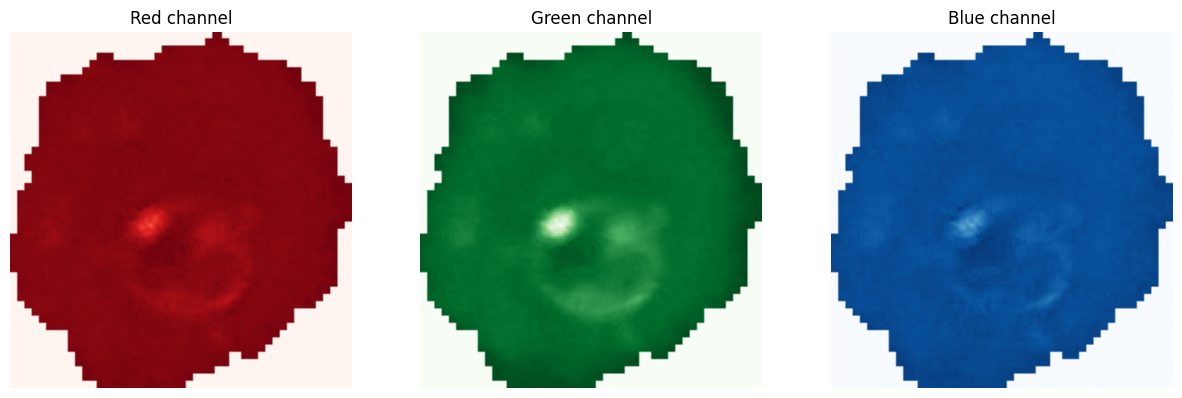

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
axs[0].imshow(parasitized_img[:,:,0], cmap='Reds')
axs[1].imshow(parasitized_img[:,:,1], cmap='Greens')
axs[2].imshow(parasitized_img[:,:,2], cmap='Blues')
axs[0].axis('off')
axs[1].axis('off')
axs[2].axis('off')
axs[0].set_title('Red channel')
axs[1].set_title('Green channel')
axs[2].set_title('Blue channel')
plt.show()

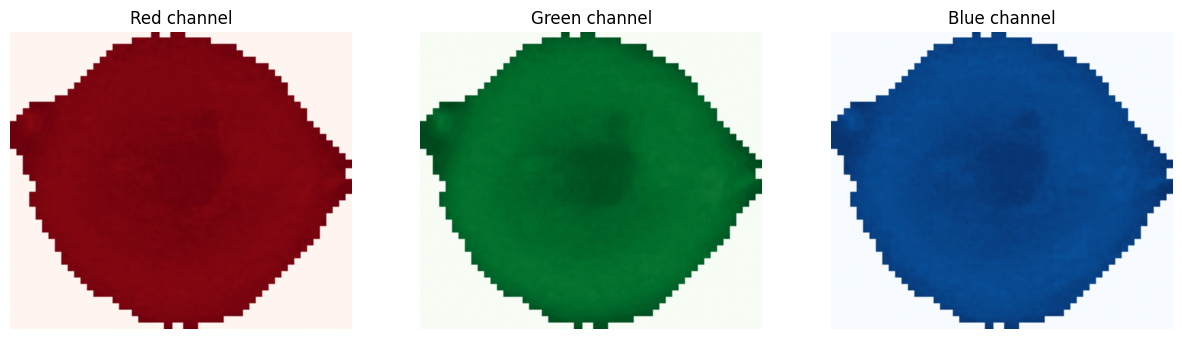

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
axs[0].imshow(uninfected_img[:,:,0], cmap='Reds')
axs[1].imshow(uninfected_img[:,:,1], cmap='Greens')
axs[2].imshow(uninfected_img[:,:,2], cmap='Blues')
axs[0].axis('off')
axs[1].axis('off')
axs[2].axis('off')
axs[0].set_title('Red channel')
axs[1].set_title('Green channel')
axs[2].set_title('Blue channel')
plt.show()

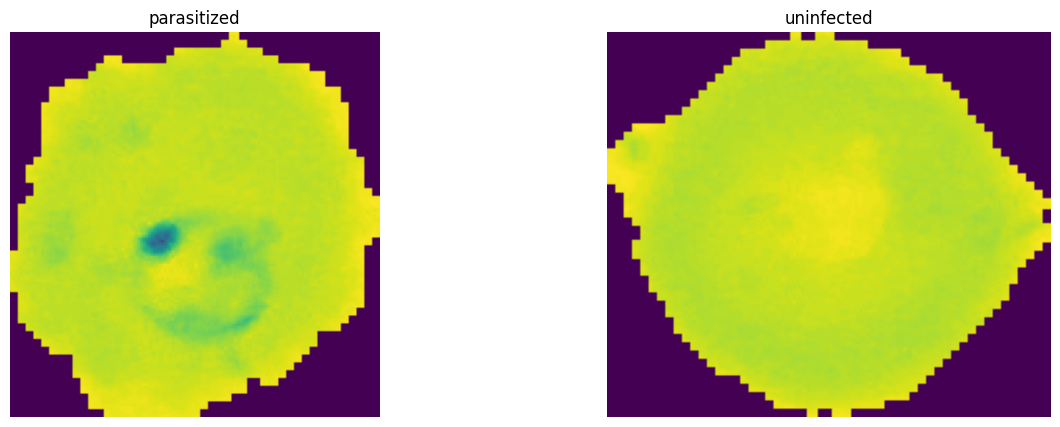

In [ ]:
fig , ax = plt.subplots(1, 2 , figsize= (15,5))

parasitized_imggray = cv2.cvtColor(parasitized_img, cv2.COLOR_RGB2GRAY)
uninfected_imggray = cv2.cvtColor(uninfected_img, cv2.COLOR_RGB2GRAY)

ax[0].imshow(parasitized_imggray)
ax[1].imshow(uninfected_imggray)

ax[0].axis('off')
ax[1].axis('off')

ax[0].set_title('parasitized')
ax[1].set_title('uninfected')

plt.show()

In [ ]:
print('parasitized gray' , parasitized_imggray.shape)
print('uninfected gray' , uninfected_imggray.shape)

parasitized gray (148, 142)
uninfected gray (139, 160)


In [ ]:
img = parasitized_imggray
template = cv2.resize(cv2.imread(r"C:\Users\dohah\Documents\Projects\Detecting Malaria Model\MachineLearningProject\img_dataset\template.png", 0), (0, 0), fx=0.8, fy=0.8)
h, w = template.shape

methods = [cv2.TM_CCOEFF, cv2.TM_CCOEFF_NORMED, cv2.TM_CCORR,
            cv2.TM_CCORR_NORMED, cv2.TM_SQDIFF, cv2.TM_SQDIFF_NORMED]

for method in methods:
    img2 = img.copy()

    result = cv2.matchTemplate(img2, template, method)
    min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(result)
    if method in [cv2.TM_SQDIFF, cv2.TM_SQDIFF_NORMED]:
        location = min_loc
    else:
        location = max_loc

    # ارسم المربع
    bottom_right = (location[0] + w, location[1] + h)
    cv2.rectangle(img2, location, bottom_right, (255, 0, 0), 3)

    # حولي الصورة من BGR → RGB عشان plt يقرها صح
    img_rgb = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

    # اعرضي الصورة
    plt.figure(figsize=(6,6))
    plt.imshow(img_rgb)
    plt.axis('off')   # يشيل الإحداثيات
    plt.show()

    # bottom_right = (location[0] + w, location[1] + h)    
    # cv2.rectangle(img2, location, bottom_right, 255, 5)
    # cv2.imshow('Match', img2)
    # cv2.waitKey(0)
    # cv2.destroyAllWindows()
